In [ ]:
from qutip_solver import simulate_heisenberg
from naive_adc_circuit import naive_circuit, solve_qc

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

from qiskit_aer import AerSimulator

In [4]:
n = 3
J = [1/4]*(n - 1)
gamma = [J[0]/4]*n
tlist = np.linspace(0, 25, 100)
excited = ["0"]
k = 2
dissipation = True

backend = AerSimulator()

In [7]:
pops, result = simulate_heisenberg(J, gamma, n, excited, tlist, dissipation)

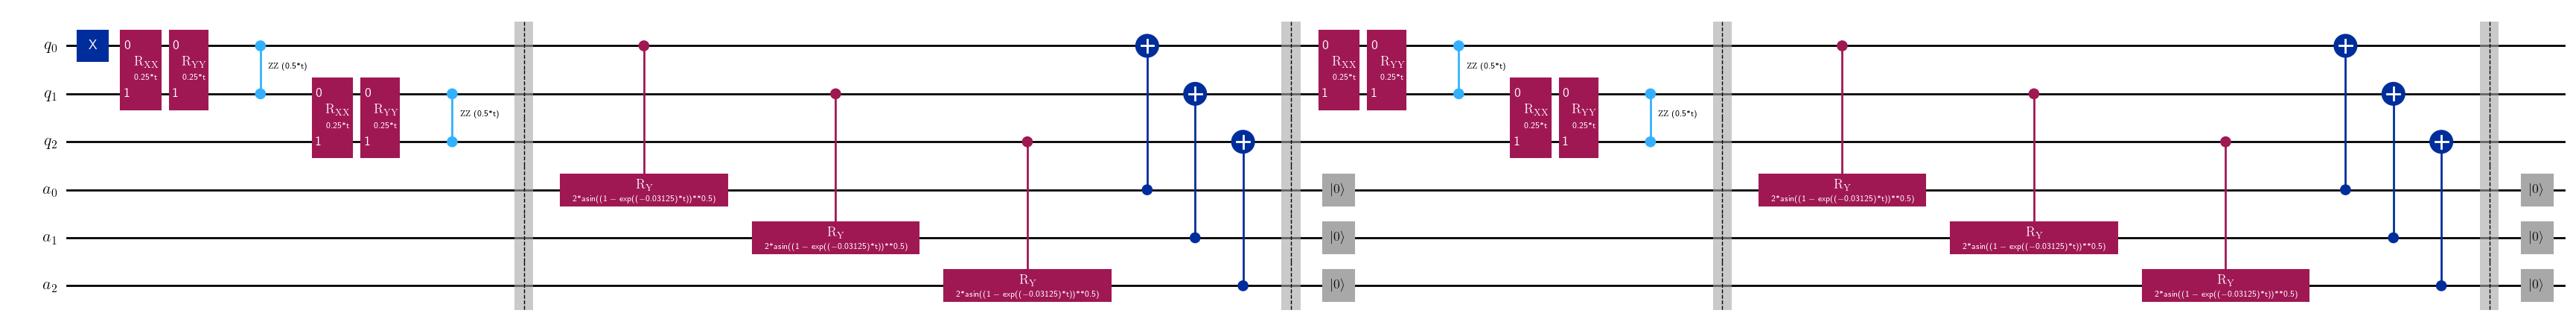

In [3]:
qc = naive_circuit(J, gamma, n, excited, k, dissipation)
qc.draw('mpl', fold = -1)

In [5]:
evs = solve_qc(n, qc, tlist, backend)

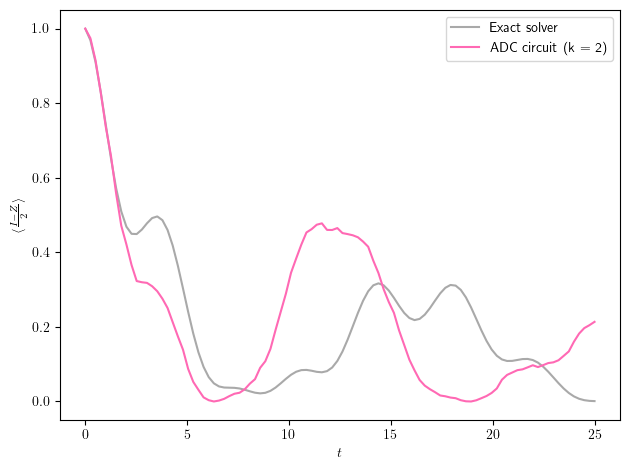

In [8]:
plot_qubits = [0]
for i in plot_qubits:
    plt.plot(tlist, pops[i], color = 'darkgrey', label = "Exact solver")
    plt.plot(tlist, evs[str(i)], color = 'hotpink', label = f"ADC circuit (k = {k})")
    
plt.ylabel(r"$\langle \frac{I - Z}{2} \rangle$")
plt.xlabel("$t$")
plt.legend()
plt.tight_layout()
plt.show()